# **PHYSICALLY INFORMED DOS PREDICTICTION - ALLOY SURFACE DATASET**

## Mounting The Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Installing Dependencies

In [2]:
!pip install torch torchvision

In [16]:
import torch
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

torch version: 2.3.0+cu121
CUDA available: True
CUDA version: 12.1


In [4]:
# Installing required packages
# To ensure compatibility with PyTorch Geometric's pre-compiled wheels for CUDA 12.x in Colab,
# it's often necessary to install a specific, known-working PyTorch version.
# We will install PyTorch 2.3.0 with CUDA 12.1 (which works with Colab's CUDA 12.8 drivers).
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121

# Install torch-scatter and torch-sparse (these will likely install numpy 2.x and scipy 1.18.0 initially)
!pip install torch-scatter torch-sparse torch-cluster torch-geometric torch-spline-conv -f https://data.pyg.org/whl/torch-2.3.0+cu121.html --force-reinstall

# Install other dependencies like matminer, pymatgen, ase
!pip install matminer pymatgen ase

# Fix for numpy/scipy incompatibility: Forcefully downgrade numpy and scipy LAST
# This addresses the ImportError: cannot import name '_center' from 'numpy._core.umath'
# by ensuring that numpy 1.x and a compatible scipy version are the final installed versions.
# We'll use scipy==1.17.0 as it's the minimum required by pymatgen and is compatible with numpy 1.x.
!pip install numpy==1.26.4 scipy==1.17.0 --force-reinstall

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 124.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 104.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 213.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 268.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 140.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 62.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 68.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 115.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 125.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 92.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/19

Looking in links: https://data.pyg.org/whl/torch-2.3.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 101.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 88.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 92.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.6/949.6 kB 61.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.3 MB/s eta 0:00:00
  Create

In [2]:
pwd

'/content'

In [3]:
cd drive/MyDrive/MatDeepLearn_DOS/

/content/drive/MyDrive/MatDeepLearn_DOS


In [4]:
# !git clone https://github.com/vxfung/MatDeepLearn_DOS # Only if repo is not cloned
# !cd MatDeepLearn_DOS
!pip install numpy scipy matplotlib joblib dscribe scikit_learn ase pymatgen ray PyYAML pickle
!pip install ray
!pip install dscribe
!pip install PyYAML
!pip install pickle


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle
  Using cached ray-2.57.0-cp312-cp312-manylinux2014_x86_64.whl.metadata (23 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 MB 9.7 MB/s eta 0:00:00
  Using cached dscribe-2.1.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.4/777.4 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 19.6 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


## Pre-Processing

In [5]:
pwd

'/content/drive/MyDrive/MatDeepLearn_DOS'

In [6]:
cd data


/content/drive/MyDrive/MatDeepLearn_DOS/data


In [7]:
ls

alloy_data/  bulk_dos/  srtio3_data/  surface_dos/
bulk_data/   README.md  STO_dos/


In [8]:
cd alloy_data

/content/drive/MyDrive/MatDeepLearn_DOS/data/alloy_data


In [9]:
ls

surface_DOS_dataset/  surface_DOS_dataset.tar.gz


In [12]:
# Copy your already-downloaded SrTiO3 data into a location main.py can point to
# !mkdir -p /content/MatDeepLearn_DOS/run_data
!mkdir -p /content/drive/MyDrive/MatDeepLearn_DOS/run_data_alloy_surf
!cp surface_DOS_dataset/*.vasp surface_DOS_dataset/*.npy surface_DOS_dataset/targets.csv /content/drive/MyDrive/MatDeepLearn_DOS/run_data_alloy_surf/
!ls /content/drive/MyDrive/MatDeepLearn_DOS/run_data_alloy_surf | wc -l   # should print 3827 (1913×2 + 1 targets.csv)

3827


In [13]:
cd ..

/content/drive/MyDrive/MatDeepLearn_DOS/data


In [14]:
cd ..

/content/drive/MyDrive/MatDeepLearn_DOS


In [15]:
# Editing config.yml - disabling SOAP/LMBTR since DOS_STO (DOSpredict model) doesn't use them
import re

config_path = "/content/drive/MyDrive/MatDeepLearn_DOS/config.yml"
with open(config_path, "r") as f:
    config_text = f.read()

config_text = config_text.replace('SOAP_descriptor: "True"', 'SOAP_descriptor: "False"')
config_text = config_text.replace('LMBTR_descriptor: "True"', 'LMBTR_descriptor: "False"')

with open(config_path, "w") as f:
    f.write(config_text)

# Verify the change took
!grep -A0 "SOAP_descriptor\|LMBTR_descriptor" /content/drive/MyDrive/MatDeepLearn_DOS/config.yml

    LMBTR_descriptor: "False"
--
    SOAP_descriptor: "False"


## Training Process

In [17]:
!python /content/drive/MyDrive/MatDeepLearn_DOS/main.py --data_path='/content/drive/MyDrive/MatDeepLearn_DOS/run_data_alloy_surf' --model='DOS_surf' --run_mode='Training' --job_name='reproduce_alloy_surface' --save_model='True' --model_path='alloy_surface_model.pth'

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
Starting...
GPU is available: True , Quantity:  1
Settings: 
{'Job': {'job_name': 'reproduce_alloy_surface',
         'load_model': 'False',
         'model': 'DOS_surf',
         'model_path': 'alloy_surface_model.pth',
         'parallel': 'True',
         'reprocess': 'False',
         'save_model': 'True',
         'seed': 95969,
         'write_output': 'True'},
 'Models': {'batch_norm': 'True',
            'batch_size': 50,
            'batch_track_stats': 'False',
            'dim1': 350,
            'dim2': 270,
            'dropout_rate': 0.1,
            'epochs': 800,
            'gc_count': 6,
            'lr': 0.00057,
            'model': 'DOSpredict',
            'optimizer': 'AdamW',
            'optimizer_args': {'weight_decay': 0.01},
           

In [18]:
pwd

'/content/drive/MyDrive/MatDeepLearn_DOS'

## Analyzing Outputs

### Analyzing Predicted DOS Output

In [19]:
import pandas as pd
import numpy as np

df_main = pd.read_csv("reproduce_alloy_surface_test_outputs.csv")
print("Shape:", df_main.shape)
print("Columns (first 15):", df_main.columns[:15].tolist())
print("Columns (last 10):", df_main.columns[-10:].tolist())
df_main.head()

Shape: (3431, 806)
Columns (first 15): ['ids', 'element', 'loss_l1', 'loss_rmse', 'target', 'target.1', 'target.2', 'target.3', 'target.4', 'target.5', 'target.6', 'target.7', 'target.8', 'target.9', 'target.10']
Columns (last 10): ['prediction.391', 'prediction.392', 'prediction.393', 'prediction.394', 'prediction.395', 'prediction.396', 'prediction.397', 'prediction.398', 'prediction.399', 'prediction.400']


,ids,element,loss_l1,loss_rmse,target,target.1,target.2,target.3,target.4,target.5,...,prediction.391,prediction.392,prediction.393,prediction.394,prediction.395,prediction.396,prediction.397,prediction.398,prediction.399,prediction.400
0,696,25,0.086482,0.175871,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000008,0.000009,0.000008,0.000006,0.000006,0.000006,0.000007,0.000007,NaN,NaN
1,696,25,0.085438,0.174921,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000008,0.000009,0.000008,0.000006,0.000006,0.000006,0.000007,0.000007,NaN,NaN
2,696,41,0.045595,0.095930,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000005,0.000004,0.000005,0.000004,0.000004,0.000005,0.000005,0.000004,NaN,NaN
3,696,41,0.044473,0.094031,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000005,0.000004,0.000005,0.000004,0.000004,0.000005,0.000005,0.000004,NaN,NaN
4,696,25,0.152964,0.340742,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000005,0.000008,0.000005,0.000005,0.000004,0.000005,0.000008,0.000007,NaN,NaN


### Analyzing Predicted DOS Derived Features Output

In [20]:
df_feat = pd.read_csv("reproduce_alloy_surface_test_outputs_features.csv")
print("Shape:", df_feat.shape)
print("Columns:", df_feat.columns.tolist())
df_feat.head()

Shape: (3431, 17)
Columns: ['ids', 'element', 'loss_l1', 'loss_l1.1', 'loss_l1.2', 'loss_l1.3', 'loss_l1.4', 'target', 'target.1', 'target.2', 'target.3', 'target.4', 'prediction', 'prediction.1', 'prediction.2', 'prediction.3', 'prediction.4']


,ids,element,loss_l1,loss_l1.1,loss_l1.2,loss_l1.3,loss_l1.4,target,target.1,target.2,target.3,target.4,prediction,prediction.1,prediction.2,prediction.3,prediction.4
0,696,25,0.133764,0.281645,0.050270,0.095867,0.641570,-0.742381,2.998783,-0.019101,2.219207,2.806309,-0.876145,3.280428,0.031170,2.123339,2.164739
1,696,25,0.127705,0.293523,0.050581,0.099459,0.641467,-0.748439,2.986909,-0.019412,2.222799,2.806204,-0.876144,3.280431,0.031169,2.123339,2.164737
2,696,41,0.012707,0.376333,0.022896,0.116986,0.022443,-0.490103,3.414259,-0.341143,2.089014,1.470405,-0.502810,3.037926,-0.318247,2.206000,1.492848
3,696,41,0.000815,0.360865,0.020704,0.115580,0.021762,-0.501994,3.398792,-0.338951,2.090420,1.471085,-0.502810,3.037927,-0.318247,2.206000,1.492847
4,696,25,0.055911,0.539800,0.146355,0.190848,0.899614,-0.928424,2.930957,-0.192481,2.287119,3.050909,-0.984335,3.470757,-0.046126,2.096271,2.151295


### Refining The Outputs

In [21]:
# Ignore the mislabeled headers entirely - the real underlying data is simply:
# columns 0-3 = metadata (ids, element, loss_l1, loss_rmse)
# columns 4-403 = real target values (400 of them)
# columns 404-803 = real prediction values (400 of them)
# columns 804-805 = genuinely empty (NaN), an artifact of the header's off-by-one bug

meta = df_main.iloc[:, 0:4]
meta.columns = ["ids", "element", "loss_l1", "loss_rmse"]

targets = df_main.iloc[:, 4:404].values      # (3734, 400)
predictions = df_main.iloc[:, 404:804].values  # (3734, 400)

print("targets shape:", targets.shape, "| NaN present:", np.isnan(targets).any())
print("predictions shape:", predictions.shape, "| NaN present:", np.isnan(predictions).any())

ids = meta["ids"].values
elements = meta["element"].values
loss_l1_per_atom = meta["loss_l1"].values   # already-computed per-atom MAE, straight from their code

targets shape: (3431, 400) | NaN present: False
predictions shape: (3431, 400) | NaN present: False


## DOS Derived Features MAE Prediction

In [37]:
feature_names = ["band_center", "band_width", "skew", "kurtosis", "states_near_ef"]
loss_l1_cols = ["loss_l1", "loss_l1.1", "loss_l1.2", "loss_l1.3", "loss_l1.4"]

# This IS the paper's Table 1 "derived feature MAE" - just average each column
# across the whole test set, exactly like L_DOS was averaged to get 0.038
feature_mae = df_feat[loss_l1_cols].mean()
feature_mae.index = feature_names

print("Reproduced feature MAEs (compare to Table 1's SrTiO3 row):")
print(f"{'Feature':<18}{'Yours':<10}{'Paper':<10}")
paper_values = {"band_center":  0.094, "band_width": 0.294 , "skew":0.075,
                 "kurtosis": 0.188, "states_near_ef":  0.133}
for name in feature_names:
    print(f"{name:<18}{feature_mae[name]:<10.4f}{paper_values[name]:<10.4f}")

Reproduced feature MAEs (compare to Table 1's SrTiO3 row):
Feature           Yours     Paper     
band_center       0.1009    0.0940    
band_width        0.3050    0.2940    
skew              0.0766    0.0750    
kurtosis          0.2008    0.1880    
states_near_ef    0.1370    0.1330    


# Plotting

### Selecting An Id

In [36]:
df_main_clean = meta.copy()
df_main_clean["targets_arr"] = list(targets)
df_main_clean["predictions_arr"] = list(predictions)

struct_mean_mae = df_main_clean.groupby("ids")["loss_l1"].mean().sort_values()
median_struct_id = struct_mean_mae.index[len(struct_mean_mae) // 2]
median_mae_value = struct_mean_mae.loc[median_struct_id]

print(f"Selected structure_id={median_struct_id} with mean per-atom MAE={median_mae_value:.4f} "
      f"(median across {len(struct_mean_mae)} test structures)")

# check what elements are actually in this structure before plotting
struct_rows_check = df_main_clean[df_main_clean["ids"] == median_struct_id]
print("Elements (atomic numbers) in this structure:", sorted(struct_rows_check["element"].unique()))

Selected structure_id=549 with mean per-atom MAE=0.0816 (median across 286 test structures)
Elements (atomic numbers) in this structure: [41, 50]


### The Plot

Selected structures (near median error):
  structure 1426: MAE=0.0814
  structure 549: MAE=0.0816
  structure 1337: MAE=0.0821
  structure 235: MAE=0.0826


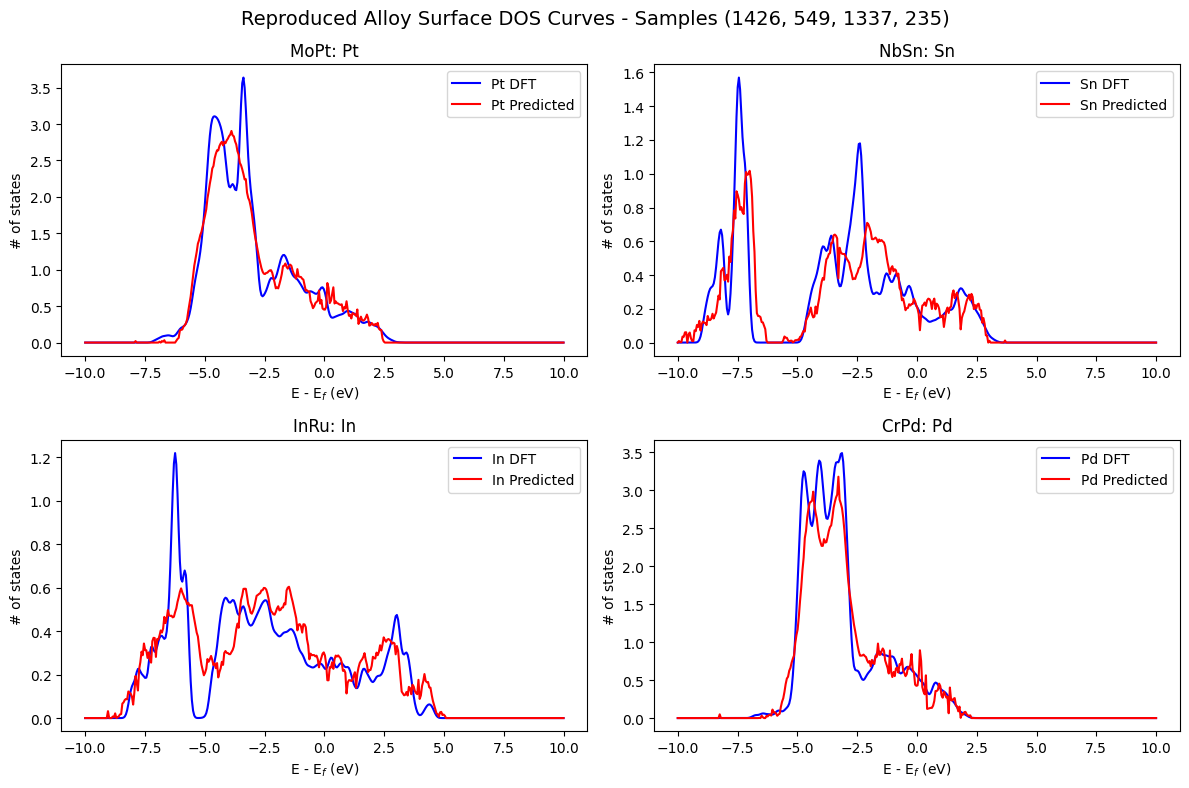

In [43]:
import matplotlib.pyplot as plt

# Full element symbol lookup for the alloy surface dataset's 37 species
Z_TO_SYMBOL = {
    13: "Al", 21: "Sc", 22: "Ti", 23: "V", 24: "Cr", 25: "Mn", 26: "Fe", 27: "Co",
    28: "Ni", 29: "Cu", 30: "Zn", 31: "Ga", 39: "Y", 40: "Zr", 41: "Nb", 42: "Mo",
    43: "Tc", 44: "Ru", 45: "Rh", 46: "Pd", 47: "Ag", 48: "Cd", 49: "In", 50: "Sn",
    57: "La", 72: "Hf", 73: "Ta", 74: "W", 75: "Re", 76: "Os", 77: "Ir", 78: "Pt",
    79: "Au", 80: "Hg", 81: "Tl", 82: "Pb", 83: "Bi",
}

energies = np.linspace(-10, 10, 400)

# --- Selecting 4 structures, all close to the median-error position (matching the
#     paper's "50th quantile" selection used across all four Figure 3 panels) ---
n_structs = len(struct_mean_mae)
median_pos = n_structs // 2
selected_positions = [median_pos - 1, median_pos, median_pos + 1, median_pos + 2]
selected_struct_ids = [struct_mean_mae.index[p] for p in selected_positions]

print("Selected structures (near median error):")
for sid in selected_struct_ids:
    print(f"  structure {sid}: MAE={struct_mean_mae.loc[sid]:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, sid in zip(axes, selected_struct_ids):
    struct_rows = df_main_clean[df_main_clean["ids"] == sid]

    elements_here = struct_rows["element"].unique()
    element_counts = struct_rows["element"].value_counts()

    # picking the minority element (fewer atoms) as the representative curve to show,
    # similar in spirit to the paper's examples (e.g. W in Ru3W, In in RhIn)
    plot_z = element_counts.idxmin()

    elem_rows = struct_rows[struct_rows["element"] == plot_z]
    true_curve = np.stack(elem_rows["targets_arr"].values).mean(axis=0)
    pred_curve = np.stack(elem_rows["predictions_arr"].values).mean(axis=0)

    plot_symbol = Z_TO_SYMBOL.get(plot_z, f"Z={plot_z}")
    all_symbols = sorted([Z_TO_SYMBOL.get(z, f"Z={z}") for z in elements_here])
    structure_name = "".join(all_symbols)  # e.g. "NbSn"

    ax.plot(energies, true_curve, color="blue", label=f"{plot_symbol} DFT")
    ax.plot(energies, pred_curve, color="red", label=f"{plot_symbol} Predicted")
    ax.set_xlabel("E - E$_f$ (eV)")
    ax.set_ylabel("# of states")
    ax.set_title(f"{structure_name}: {plot_symbol}")
    ax.legend()

plt.suptitle("Reproduced Alloy Surface DOS Curves - Samples (1426, 549, 1337, 235)", fontsize=14)
plt.tight_layout()
plt.savefig("figure3_alloy_surface_reproduction.png", dpi=200)
plt.show()

# Calculating Coefficient Of Determination $R^2$

$R^2$ answers the question: "of all the variation that exists in the true DOS values (means, how different are the true DOS values from each other, across the whole dataset?), what fraction does my model's predictions successfully capture?

In [40]:
mae = np.mean(np.abs(predictions - targets))
rmse = np.sqrt(np.mean((predictions - targets) ** 2))
print(f"DOS MAE:  {mae:.4f}  (paper: 0.102)")
print(f"DOS RMSE: {rmse:.4f}  (paper: 0.258)")

def r_squared(true, pred):
    true_flat, pred_flat = true.flatten(), pred.flatten()
    ss_res = np.sum((true_flat - pred_flat) ** 2)
    ss_tot = np.sum((true_flat - np.mean(true_flat)) ** 2)
    return 1 - ss_res / ss_tot

r2 = r_squared(targets, predictions)
print(f"R² = {r2:.4f}  ({r2*100:.2f}% of variance explained)")

DOS MAE:  0.1097  (paper: 0.102)
DOS RMSE: 0.4269  (paper: 0.258)
R² = 0.7987  (79.87% of variance explained)
